In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(0, '../')  # adjust based on where your notebook is
from scripts.download_data import get_clinical_patient_data, get_clinical_sample_data
sns.set_theme(style='whitegrid', context='paper')


MSK LUAD Data Download from cBioPortal


In [5]:
STUDY_ID = "luad_mskcc_2023_met_organotropism"
clinical_patient= get_clinical_patient_data(STUDY_ID)
clinical_sample = get_clinical_sample_data(STUDY_ID)



[4/4] Downloading patient-level clinical data...
   ✓ 2298 patients × 33 columns

[3/4] Downloading sample-level clinical data...
   ✓ 2653 samples × 60 columns


In [6]:
clinical_sample['patientId'] = clinical_sample['sampleId'].str.extract(r'(P-\d+)') # get the patient id from sample id
df = pd.merge(clinical_patient, clinical_sample, how='inner', on='patientId')
df = df[df['GROUP_NO'].isin(['Group1', 'Group2'])]


In [7]:
target_cols = ['EVER_MET_SITE_ADRENAL', 'EVER_MET_SITE_BONE', 'EVER_MET_SITE_CNS',
               'EVER_MET_SITE_LIVER_BILIARY_TRACT', 'EVER_MET_SITE_LN', 
               'EVER_MET_SITE_LUNG', 'EVER_MET_SITE_PLEURA']

df['TMB_NONSYNONYMOUS'] = df['TMB_NONSYNONYMOUS'].astype(float)

df[target_cols] = df[target_cols].astype(int)


df['EVER_MET'] = (df[target_cols].sum(axis=1) > 0).astype(int)


In [8]:
df.columns


Index(['patientId', 'ADJUVANT', 'ADJUVANT_CHEMOTHERAPY',
       'ADJUVANT_IMMUNOTHERAPY', 'ADJUVANT_TARGETED', 'ADJUVANT_XRT',
       'ADRENAL_MONTHS', 'ADRENAL_STATUS', 'BONE_MONTHS', 'BONE_STATUS',
       'CIGARETTE_HX', 'CNS_MONTHS', 'CNS_STATUS', 'HAD_SURGERY',
       'LIVER_MONTHS', 'LIVER_STATUS', 'LN_MONTHS', 'LN_STATUS', 'LUNG_MONTHS',
       'LUNG_STATUS', 'MONTHS_FROM_MATCHED_PRIM', 'NEOADJUVANT',
       'NEOADJUVANT_CHEMOTHERAPY', 'NEOADJUVANT_IMMUNOTHERAPY',
       'NEOADJUVANT_TARGETED', 'NEOADJUVANT_XRT', 'OS_MONTHS', 'OS_STATUS',
       'PLEURA_MONTHS', 'PLEURA_STATUS', 'RACE', 'SAMPLE_COUNT', 'SEX',
       'sampleId', 'ADJUVANT_THERAPY', 'AGE_AT_DOS_BX', 'CANCER_TYPE',
       'CANCER_TYPE_DETAILED', 'CELL_CYCLE', 'CSTAGE', 'DEATH',
       'EVER_MET_SITE_ADRENAL', 'EVER_MET_SITE_BONE', 'EVER_MET_SITE_CNS',
       'EVER_MET_SITE_LIVER_BILIARY_TRACT', 'EVER_MET_SITE_LN',
       'EVER_MET_SITE_LUNG', 'EVER_MET_SITE_PLEURA', 'FGA',
       'FRACTION_GENOME_ALTERED', 'FU_2YRS'

In [25]:
print(df['RACE'].value_counts())


RACE
White      472
Asian       56
Black       19
Unknown     16
Other       13
Name: count, dtype: int64


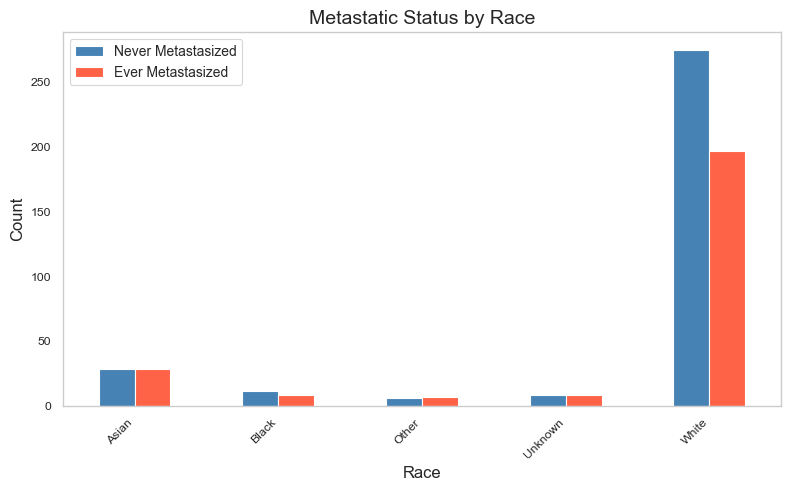

In [10]:

fig, ax = plt.subplots(figsize=(8, 5))
race_met = df.groupby(['RACE', 'EVER_MET']).size().unstack(fill_value=0)
race_met.columns = ['Never Metastasized', 'Ever Metastasized']
race_met.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Metastatic Status by Race', fontsize=14)
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../results/figures/race_distribution.png', dpi=300)
plt.show()


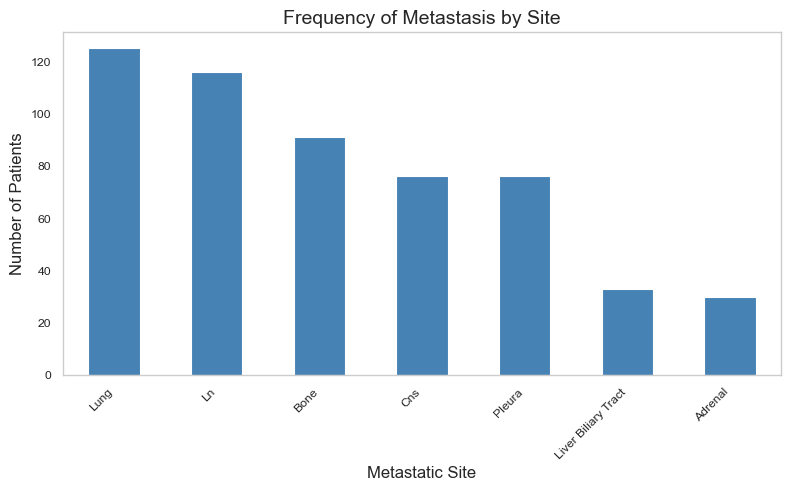

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
label_counts = df[target_cols].sum().sort_values(ascending=False)
label_counts.index = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
                      for col in label_counts.index]
label_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Metastatic Site', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Frequency of Metastasis by Site', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../results/figures/label_frequency.png', dpi=300)
plt.show()


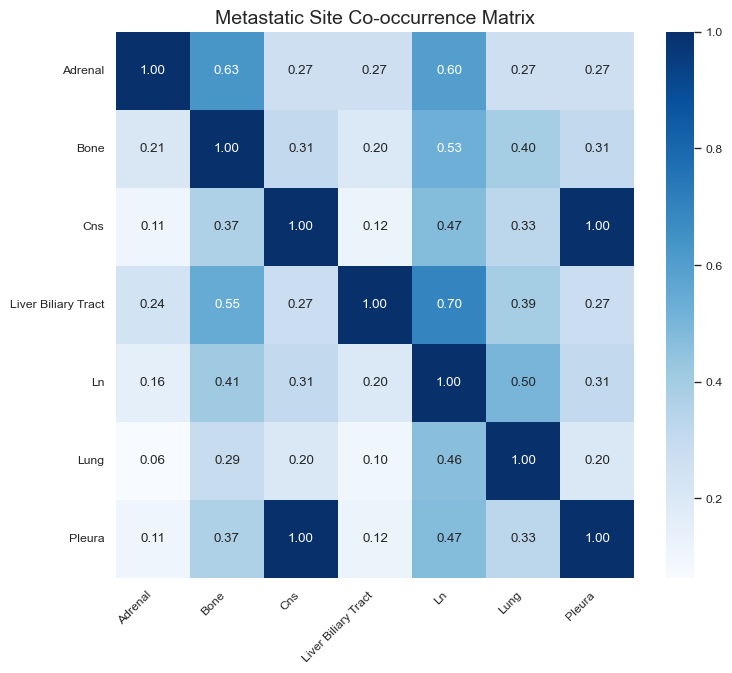

In [12]:
# co-occurence matrix
import numpy as np

fig, ax = plt.subplots(figsize=(8, 7))

# compute co-occurrence matrix
cooccurrence = df[target_cols].T.dot(df[target_cols])
cooccurrence_norm = cooccurrence.div(cooccurrence.values.diagonal(), axis=0)
# clean up labels
labels = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
          for col in target_cols]

sns.heatmap(cooccurrence_norm, 
            annot=True, 
            fmt='.2f',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues',
            ax=ax)

ax.set_title('Metastatic Site Co-occurrence Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig('../results/figures/cooccurrence_heatmap.png', dpi=300)
plt.show()


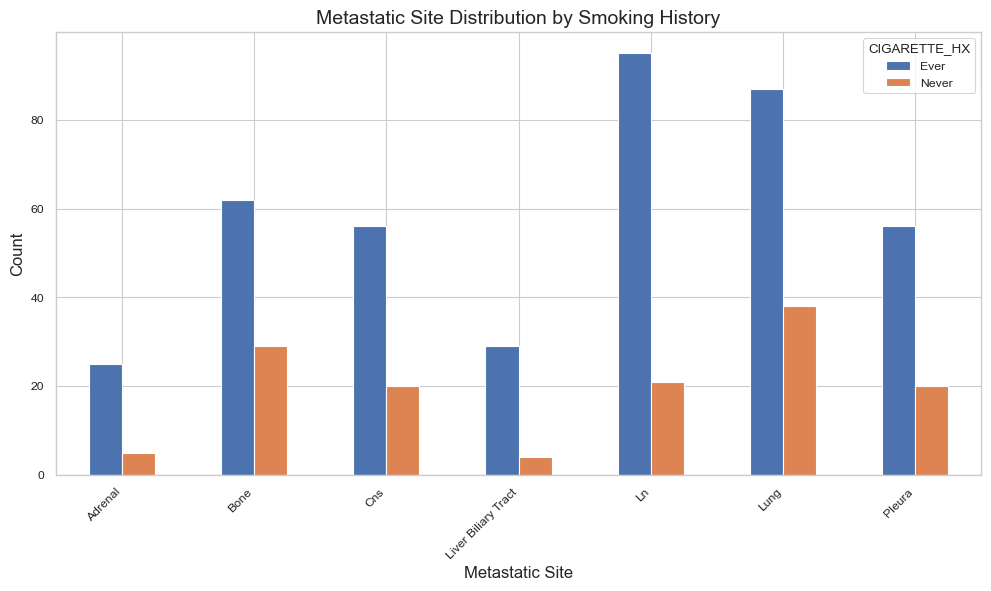

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

df_g2 = df[df['GROUP_NO'] == 'Group2']
smoking_site = df_g2.groupby('CIGARETTE_HX')[target_cols].sum()
smoking_site.columns = [col.replace('EVER_MET_SITE_', '').replace('_', ' ').title() 
                        for col in target_cols]

smoking_site.T.plot(kind='bar', ax=ax)
ax.set_xlabel('Metastatic Site', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Metastatic Site Distribution by Smoking History', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/smoking_by_site.png', dpi=300)
plt.show()


/var/folders/nt/gz5b2xbd7sl05982064yjtx00000gn/T/ipykernel_82782/1669745737.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([never_met, ever_met], labels=['Never Metastasized', 'Ever Metastasized'],


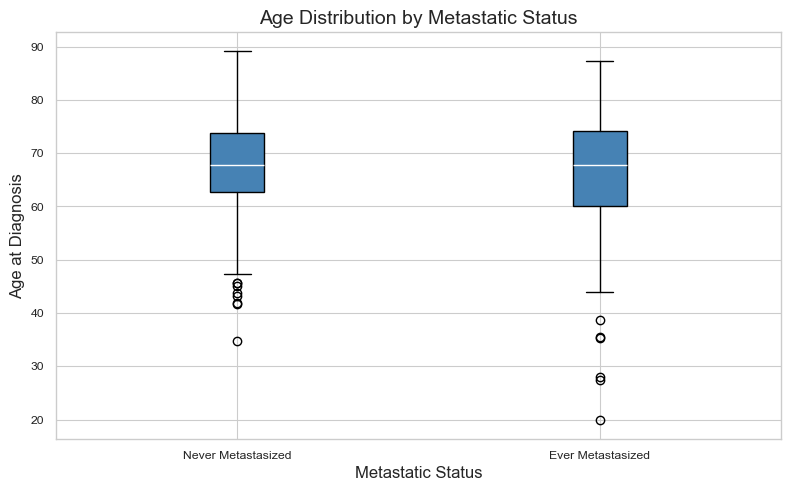

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

never_met = df[df['EVER_MET_LABEL'] == 'Never Metastasized']['AGE_AT_DOS_BX'].dropna()
ever_met = df[df['EVER_MET_LABEL'] == 'Ever Metastasized']['AGE_AT_DOS_BX'].dropna()

never_met = never_met.astype(float)
ever_met = ever_met.astype(float)

ax.boxplot([never_met, ever_met], labels=['Never Metastasized', 'Ever Metastasized'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue'),
           medianprops=dict(color='white'))

ax.set_xlabel('Metastatic Status', fontsize=12)
ax.set_ylabel('Age at Diagnosis', fontsize=12)
ax.set_title('Age Distribution by Metastatic Status', fontsize=14)
plt.tight_layout()
plt.show()
